## This section analyzes the tourism ratio, which measures how much each industry depends on tourism demand.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

# 認証が完了すると、「drive/My Drive」以下にgoogle driveのルートがマウントされる。

Mounted at /content/drive


# 1. Data loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Google Drive path (for Colab)
file_path = "/content/drive/MyDrive/Data/tsa-analysis-Japan/data/JTA_TSA_2023.xlsx"
# file_path = "../data/JTA_TSA_2023.xlsx"  # for GitHub execution

xls = pd.ExcelFile(file_path)
xls.sheet_names

In [ ]:
# Table6 を読み込み
raw = pd.read_excel(file_path, sheet_name="Table6", skiprows=6)

# 不要列を落とす（全部NaNの列）
raw = raw.dropna(axis=1, how="all")

# 先頭行を列名として使う
raw.columns = raw.columns.map(lambda x: str(x).replace("\n", "").strip())

# 行番号を振り直す
raw = raw.reset_index(drop=True)

# 1行目（Products/商品 の行）は不要なので削除
df = raw.iloc[2:].reset_index(drop=True)

# rename
df = df.rename(columns={"Unnamed: 1": "item"})
df = df.rename(columns={"観光比率（％）": "tourism_ratio"})

# 先頭2列を確認
print(df.iloc[:5, :2])
print(df.columns)

  Unnamed: 0                                               item
0        NaN                  A. Consumption products (*)\n消費商品
1        NaN       A.1. Tourism characteristic products\n観光特有商品
2        NaN     1. Accommodation services for visitors\n宿泊サービス
3        NaN  1.a. Accommodation services for visitors other...
4        NaN   1.b. Vacation home ownership (imputed)\n別荘（帰属家賃）
Index(['Unnamed: 0', 'item', '宿泊業', '宿泊業（1.bを除く）', '別荘（帰属家賃）', '飲食業', '鉄道旅客輸送',
       '道路旅客輸送', '水運', '航空輸送', 'その他の運輸業(**)', 'スポーツ・娯楽業', '観光産業　計', 'その他の産業',
       '国内観光供給サービス　計（生産者価格）', '国内観光供給財貨　計（生産者価格）', '輸入',
       '国内生産・輸入品に課される税（控除）補助金', '商業・運輸マージン', '内部観光消費', '国内供給（購入者価格）',
       'tourism_ratio'],
      dtype='object')


### 行 = 指標
### 列 = 産業

In [ ]:
!apt-get -y install fonts-ipafont-gothic > /dev/null
!apt-get update -qq
!apt-get install -y fonts-ipafont-gothic -qq

# 2. 可視化

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

plt.rcParams["font.family"] = "DejaVu Sans"

ratio_df = df[["item", "tourism_ratio"]].copy()
ratio_df["tourism_ratio"] = pd.to_numeric(ratio_df["tourism_ratio"], errors="coerce")
ratio_df = ratio_df.dropna(subset=["tourism_ratio"]).reset_index(drop=True)

ratio_df = ratio_df.sort_values("tourism_ratio", ascending=False)

# 個別カテゴリだけ
ratio_df = ratio_df[~ratio_df["item"].str.startswith("A", na=False)].copy()

# ラベルを短くする/英語部分だけ
ratio_df["item_short"] = ratio_df["item"].str.split("\n").str[0]

ratio_df

,item,tourism_ratio,item_short
4,1.b. Vacation home ownership (imputed)\n別荘（帰属家賃）,100.0,1.b. Vacation home ownership (imputed)
2,1. Accommodation services for visitors\n宿泊サービス,86.0,1. Accommodation services for visitors
8,5. Water passenger transport services\n水運旅客輸送サービス,85.5,5. Water passenger transport services
3,1.a. Accommodation services for visitors other...,85.1,1.a. Accommodation services for visitors other...
9,6. Air passenger transport services\n航空旅客輸送サービス,75.7,6. Air passenger transport services
6,3. Railway passenger transport services\n鉄道旅客輸...,47.8,3. Railway passenger transport services
10,7. Transport equipment rental services\n輸送機器レン...,23.8,7. Transport equipment rental services
5,2. Food- and beverage-serving services\n飲食サービス,19.1,2. Food- and beverage-serving services
7,4. Road passenger transport services\n道路旅客輸送サービス,16.5,4. Road passenger transport services
13,10. Sports and recreational services\nスポーツ及びレク...,13.9,10. Sports and recreational services


In [ ]:
# 純粋な“観光産業”だけ残す
valid_prefixes = tuple(str(i) + "." for i in range(1, 11))

ratio_df_clean = ratio_df[
    ratio_df["item"].str.match(r"^\d+\.", na=False)
].copy()

ratio_df_clean["item_short"] = (
    ratio_df_clean["item"]
    .str.split("\n").str[0]          # 英語だけ
    .str.replace(r"^\d+\.\s*", "", regex=True)  # 番号消す
)

ratio_df_clean = ratio_df_clean.sort_values("tourism_ratio", ascending=False)

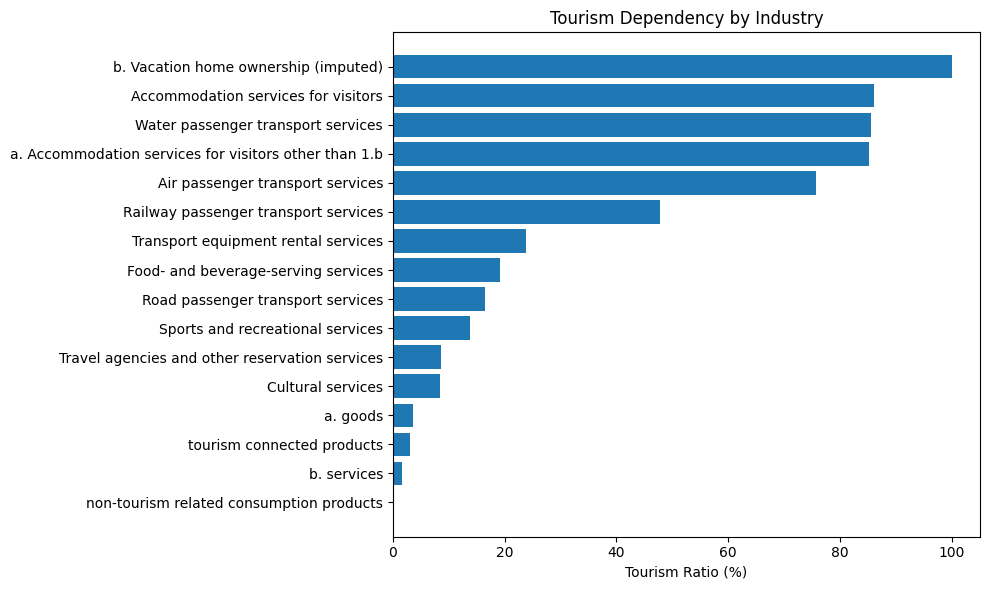

In [ ]:
plt.figure(figsize=(10, 6))
plt.barh(ratio_df_clean["item_short"], ratio_df_clean["tourism_ratio"])
plt.gca().invert_yaxis()
plt.xlabel("Tourism Ratio (%)")
plt.title("Tourism Dependency by Industry")
plt.tight_layout()
plt.show()

### 上位：宿泊・別荘・交通 → 観光依存高い
### 中位：飲食・レンタル → 中程度
### 下位：文化・物販 → 低い